# XGBoost

In [1]:
!pip install xgboost


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

In [2]:

df = pd.read_csv('final_input.csv')

In [3]:
df.shape

(1270, 439)

In [4]:
df.head()

,sample-name,AB_used,f__Enterobacteriaceae,g__Bacteroides,g__Prevotella,g__Faecalibacterium,g__Roseburia,g__Blautia,g__Alistipes,g__Bifidobacterium,...,f__Rhizobiaceae,g__Alicyclobacillus,f__Staphylococcaceae,f__Methylobacteriaceae,g__Mycoplana,g__Sharpea,f__Solirubrobacterales,f__Paenibacillaceae,g__Brachyspira,g__Tetrathiobacter
0,ERR10359977,1,0.000459,0.309954,0.004648,0.206954,0.017226,0.026215,0.041723,0.008930,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ERR10360021,1,0.000346,0.200071,0.000798,0.170797,0.129203,0.033302,0.007864,0.022578,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ERR10360103,1,0.001446,0.406406,0.000000,0.000890,0.015237,0.003225,0.038817,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ERR10360111,1,0.000000,0.440678,0.000000,0.000000,0.050847,0.000000,0.084746,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ERR10360131,1,0.000000,0.034177,0.141442,0.081260,0.029994,0.037478,0.008156,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1270 entries, 0 to 1269
Columns: 439 entries, sample-name to g__Tetrathiobacter
dtypes: float64(437), int64(1), object(1)
memory usage: 4.3+ MB


In [6]:
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

In [7]:
## checking data imbalance
sum(y)/len(y)

0.5007874015748032

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [9]:
sum(y_train)/len(y_train)

0.4881889763779528

In [10]:
sum(y_test)/len(y_test)

0.5301837270341208

In [11]:
mean_value = X_train.mean().mean()
imputer = SimpleImputer(strategy='constant', fill_value=mean_value)

In [12]:
from sklearn.preprocessing import StandardScaler
pipeline = Pipeline([
    ('imputer', imputer),  
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(n_estimators=10, max_depth=2, learning_rate=0.1, random_state=42))
])

In [13]:
param_grid = {
    'xgb__n_estimators': [100, 200], 
    'xgb__max_depth': [3, 5, 7], 
    'xgb__learning_rate': [0.01, 0.01] 
}

In [14]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=1, error_score='raise')

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

y_pred = grid_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Improved Accuracy of XG_Boost: {accuracy}')
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 7, 'xgb__n_estimators': 200}
Best Score: 0.8582682663619627
Improved Accuracy of XG_Boost: 0.8871391076115486


In [15]:
##################  SPECIFICITY and SENSITIVITY ###########################

auc = roc_auc_score(y_test, y_pred_proba)
print("XG_Boost AUC:", auc)
y_pred = grid_search.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print("XG_Boost Specificity:", specificity)
print("XG_Boost Sensitivity:", sensitivity)

XG_Boost AUC: 0.9578516510868964
XG_Boost Specificity: 0.888268156424581
XG_Boost Sensitivity: 0.8861386138613861


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.8994974874371859
Recall: 0.8861386138613861
F1 Score: 0.8927680798004988


In [17]:
import numpy as np
from sklearn.utils import resample

bootstrap_aucs = []
n_bootstraps = 1000

for _ in range(n_bootstraps):
    indices = resample(np.arange(len(y_test)), replace=True)
    y_test_sample = y_test.iloc[indices]
    X_test_sample = X_test.iloc[indices]
    
    y_pred_proba_sample = grid_search.predict_proba(X_test_sample)[:, 1]
    bootstrap_auc = roc_auc_score(y_test_sample, y_pred_proba_sample)
    bootstrap_aucs.append(bootstrap_auc)

ci_lower = np.percentile(bootstrap_aucs, 2.5)
ci_upper = np.percentile(bootstrap_aucs, 97.5)

print(f"Bootstrap 95% CI for AUC: {ci_lower:.3f} to {ci_upper:.3f}")


Bootstrap 95% CI for AUC: 0.939 to 0.974


In [18]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

bootstrap_aucs = []
bootstrap_accuracies = []
bootstrap_precisions = []
bootstrap_recalls = []
bootstrap_f1s = []
bootstrap_specificities = []
n_bootstraps = 1000

for _ in range(n_bootstraps):
    indices = resample(np.arange(len(y_test)), replace=True)
    y_test_sample = y_test.iloc[indices]
    X_test_sample = X_test.iloc[indices]
    
    y_pred_sample = grid_search.predict(X_test_sample)
    y_pred_proba_sample = grid_search.predict_proba(X_test_sample)[:, 1]
    
    
    bootstrap_auc = roc_auc_score(y_test_sample, y_pred_proba_sample)
    bootstrap_accuracy = accuracy_score(y_test_sample, y_pred_sample)
    bootstrap_precision = precision_score(y_test_sample, y_pred_sample)
    bootstrap_recall = recall_score(y_test_sample, y_pred_sample)
    bootstrap_f1 = f1_score(y_test_sample, y_pred_sample)
    
    
    tn, fp, fn, tp = confusion_matrix(y_test_sample, y_pred_sample).ravel()
    bootstrap_specificity = tn / (tn + fp)
    

    bootstrap_aucs.append(bootstrap_auc)
    bootstrap_accuracies.append(bootstrap_accuracy)
    bootstrap_precisions.append(bootstrap_precision)
    bootstrap_recalls.append(bootstrap_recall)
    bootstrap_f1s.append(bootstrap_f1)
    bootstrap_specificities.append(bootstrap_specificity)

def calculate_ci(metric_list):
    ci_lower = np.percentile(metric_list, 2.5)
    ci_upper = np.percentile(metric_list, 97.5)
    return ci_lower, ci_upper

auc_ci = calculate_ci(bootstrap_aucs)
accuracy_ci = calculate_ci(bootstrap_accuracies)
precision_ci = calculate_ci(bootstrap_precisions)
recall_ci = calculate_ci(bootstrap_recalls)
f1_ci = calculate_ci(bootstrap_f1s)
specificity_ci = calculate_ci(bootstrap_specificities)


print(f"Bootstrap 95% CI for AUC: {auc_ci[0]:.3f} to {auc_ci[1]:.3f}")
print(f"Bootstrap 95% CI for Accuracy: {accuracy_ci[0]:.3f} to {accuracy_ci[1]:.3f}")
print(f"Bootstrap 95% CI for Precision: {precision_ci[0]:.3f} to {precision_ci[1]:.3f}")
print(f"Bootstrap 95% CI for Recall (Sensitivity): {recall_ci[0]:.3f} to {recall_ci[1]:.3f}")
print(f"Bootstrap 95% CI for F1 Score: {f1_ci[0]:.3f} to {f1_ci[1]:.3f}")
print(f"Bootstrap 95% CI for Specificity: {specificity_ci[0]:.3f} to {specificity_ci[1]:.3f}")


Bootstrap 95% CI for AUC: 0.939 to 0.974
Bootstrap 95% CI for Accuracy: 0.858 to 0.916
Bootstrap 95% CI for Precision: 0.862 to 0.938
Bootstrap 95% CI for Recall (Sensitivity): 0.839 to 0.928
Bootstrap 95% CI for F1 Score: 0.862 to 0.922
Bootstrap 95% CI for Specificity: 0.844 to 0.931


In [19]:
bootstrap_aucs = []
n_bootstraps = 1000

for _ in range(n_bootstraps):
    indices = resample(np.arange(len(y_test)), replace=True)
    y_test_sample = y_test.iloc[indices]
    X_test_sample = X_test.iloc[indices]
    
    y_pred_proba_sample = grid_search.predict_proba(X_test_sample)[:, 1]
    bootstrap_auc = roc_auc_score(y_test_sample, y_pred_proba_sample)
    bootstrap_aucs.append(bootstrap_auc)

ci_lower = np.percentile(bootstrap_aucs, 2.5)
ci_upper = np.percentile(bootstrap_aucs, 97.5)

print(f"Bootstrap 95% CI for AUC: {ci_lower:.3f} to {ci_upper:.3f}")

original_auc = roc_auc_score(y_test, grid_search.predict_proba(X_test)[:, 1])

n_permutations = 10000
perm_aucs = []

for _ in range(n_permutations):
    y_test_permuted = np.random.permutation(y_test)
    perm_auc = roc_auc_score(y_test_permuted, grid_search.predict_proba(X_test)[:, 1])
    perm_aucs.append(perm_auc)

perm_aucs = np.array(perm_aucs)
p_value = np.mean(perm_aucs >= original_auc)

print(f"Permutation test p-value for AUC: {p_value:.3f}")


Bootstrap 95% CI for AUC: 0.940 to 0.975
Permutation test p-value for AUC: 0.000


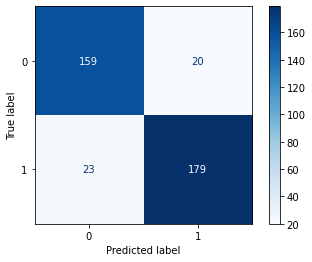

In [20]:
################### CONFUSION MATRIX   #####################


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_search.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()


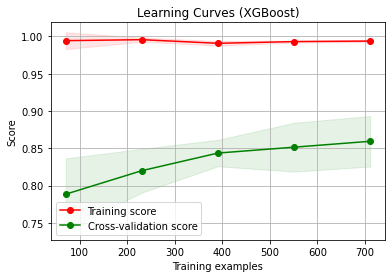

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

title = "Learning Curves (XGBoost)"
estimator = grid_search.best_estimator_ 
plot_learning_curve(estimator, title, X_train, y_train, cv=5, n_jobs=-1)

plt.show()
